In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

HOME = os.environ['HOME']
TEUFEL_DIR = HOME+'/Programming/TEUFEL'

sys.path.append(TEUFEL_DIR+'/scripts')
import teufel
import sdds
import h5py

import scipy.constants as sc
mec2 = sc.m_e*sc.c**2 / sc.e

In [2]:
!ls

dali_u100_snapshot.xml		      dali-u100-superradiance_snap_1640.h5
dali-u100-superradiance_snap_1000.h5  dali-u100-superradiance_snap_1660.h5
dali-u100-superradiance_snap_1020.h5  dali-u100-superradiance_snap_1680.h5
dali-u100-superradiance_snap_1040.h5  dali-u100-superradiance_snap_1700.h5
dali-u100-superradiance_snap_1060.h5  dali-u100-superradiance_snap_1720.h5
dali-u100-superradiance_snap_1080.h5  dali-u100-superradiance_snap_1740.h5
dali-u100-superradiance_snap_1100.h5  dali-u100-superradiance_snap_1760.h5
dali-u100-superradiance_snap_1120.h5  dali-u100-superradiance_snap_1780.h5
dali-u100-superradiance_snap_1140.h5  dali-u100-superradiance_snap_1800.h5
dali-u100-superradiance_snap_1160.h5  dali-u100-superradiance_snap_1820.h5
dali-u100-superradiance_snap_1180.h5  dali-u100-superradiance_snap_1840.h5
dali-u100-superradiance_snap_1200.h5  dali-u100-superradiance_snap_1860.h5
dali-u100-superradiance_snap_1220.h5  dali-u100-superradiance_snap_1880.h5
dali-u100-superradiance_snap_1240

In [3]:
# open the file
hdf = h5py.File('dali-u100-superradiance_snap_1200.h5', "r")
print(hdf)
print(hdf.keys())
# Get the groups
pos_group = hdf['ObservationPosition']
Nx = pos_group.attrs.get('Nx')
Ny = pos_group.attrs.get('Ny')
print(pos_group)
print("Nx=%d Ny=%d" % (Nx,Ny))
field_group = hdf['ElMagField']
print(field_group)
par_group = hdf['ParticleCoordinates']
N_par = par_group.attrs.get('N_particles')
print(par_group)
print("Npart=%d" % N_par)
# get the data
pos = np.array(pos_group)
A = np.array(field_group)
coo = np.array(par_group)
hdf.close()

<HDF5 file "dali-u100-superradiance_snap_1200.h5" (mode r)>
<KeysViewHDF5 ['ElMagField', 'ObservationPosition', 'ParticleCoordinates']>
<HDF5 dataset "ObservationPosition": shape (5, 251, 3), type "<f8">
Nx=5 Ny=251
<HDF5 dataset "ElMagField": shape (5, 251, 6), type "<f8">
<HDF5 dataset "ParticleCoordinates": shape (10000, 6), type "<f8">
Npart=10000


In [4]:
xcenter = (Nx-1)//2
ycenter = (Ny-1)//2
centerposition = pos[xcenter][ycenter]
print("center position = ",centerposition)

center position =  [0.      0.      1.19925]


In [5]:
Ex = A[:,:,0]
Ey = A[:,:,1]
Ez = A[:,:,2]
Bx = A[:,:,3]
By = A[:,:,4]
Bz = A[:,:,5]

In [8]:
print(pos.shape)
x = pos[:,:,0]
print(np.min(x), np.max(x))
z = pos[:,:,2]
print(np.min(z), np.max(z))

(5, 251, 3)
-0.001 0.001
1.198 1.2005


In [6]:
x_part = coo[:,0]
z_part = coo[:,2]
np.mean(z_part)

1.199674686104133

In [26]:
def make_plot(fig, z_mm):
    global pos, A, coo
    # open the file
    hdf = h5py.File(f'dali-u100-superradiance_snap_{z_mm}.h5', "r")
    # Get the groups
    pos_group = hdf['ObservationPosition']
    Nx = pos_group.attrs.get('Nx')
    Ny = pos_group.attrs.get('Ny')
    field_group = hdf['ElMagField']
    par_group = hdf['ParticleCoordinates']
    N_par = par_group.attrs.get('N_particles')
    # get the data
    pos = np.array(pos_group)
    A = np.array(field_group)
    coo = np.array(par_group)
    hdf.close()
    
    Ex = A[:,:,0]
    x = pos[:,:,0]
    z = pos[:,:,2]
    x_part = coo[:,0]
    z_part = coo[:,2]
    
    top = 1e9
    cut = 1e6
    signEx = np.sign(Ex)
    absEx = np.fabs(Ex)
    logEx = np.log10(absEx+cut)
    logRange = np.log10(top)-np.log10(cut)
    logPlot = (logEx-np.log10(cut))*signEx
    loglevels = np.linspace(-logRange, logRange, num=21)
    
    ax = fig.gca()
    img = ax.contourf(z,x,logPlot,loglevels,cmap='PRGn')
    cbar = fig.colorbar(img)
    cbar.set_label('$E_x$ [MV/m]')
    cbar.set_ticks([-3,-2,-1,0,1,2,3])
    cbar.set_ticklabels(['$-10^3$','$-10^2$','$-10^1$','$\pm$1','$10^1$','$10^2$','$10^3$'])
    plt.scatter(z_part,x_part,c='r',s=5, alpha=0.05)

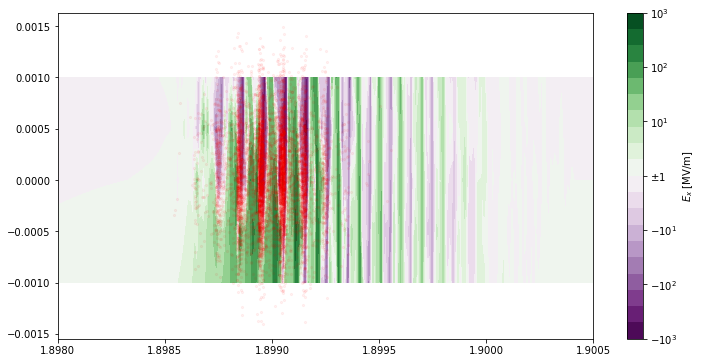

In [33]:
fig = plt.figure(figsize=(12,6))
make_plot(fig, 1900)
plt.show()

In [34]:
Ex = A[:,:,0]
z = pos[:,:,2]

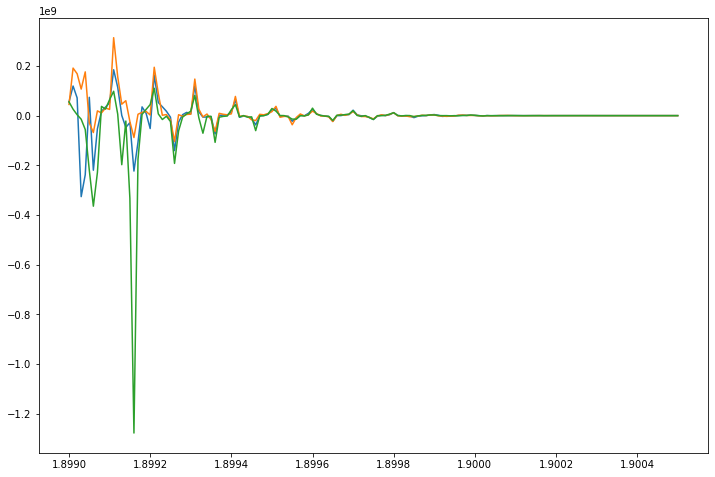

In [35]:
z_onaxis = z[2,100:]
Ex_onaxis = Ex[2,100:]
Ex_negx = Ex[1,100:]
Ex_posx = Ex[3,100:]

fig = plt.figure(figsize=(12,8))
plt.plot(z_onaxis, Ex_onaxis)
plt.plot(z_onaxis, Ex_negx)
plt.plot(z_onaxis, Ex_posx)
plt.show()